In [41]:
"""
Code for cuquantum simulation of neutrino interactions.
"""

'\nCode for cuquantum simulation of neutrino interactions.\n'

In [42]:
import qiskit as qk

# to remove the +computecanada postfix in version number, which cause error
import importlib.metadata

# Save original version
_real_version = importlib.metadata.version

# Define patch
def patched_version(pkg_name):
    if pkg_name == "qiskit":
        return _real_version(pkg_name).split("+")[0]
    return _real_version(pkg_name)

# Apply patch
importlib.metadata.version = patched_version

import numpy as np
from matplotlib import pyplot as plt

import warnings
# warnings.filterwarnings("ignore")

# Suppress the warning from importing cuquantum
from cuquantum import cutensornet as tn

# warnings.resetwarnings()

ModuleNotFoundError: No module named 'cuquantum'

In [ ]:
"""
Set up to evaluate classical solution for nunubar
"""
import numpy as np

L          = 0.1
t_steps    = 5
theta      = np.pi/2 - 0.2
dmsq       = 1.0
n_qubits   = 2
Delta      = dmsq / (2*0.1) * np.array([1.] * (n_qubits // 2) + [-1.0] * (n_qubits // 2))
b          = np.array([np.sin(2*theta), 0, -np.cos(2*theta)]) # the structure of the vacuum Hamiltonian in the Pauli basis
J          = 5 * np.ones((n_qubits, n_qubits))
nu_mask    = [True]*(n_qubits // 2) + [False] * (n_qubits // 2)
nubar_mask = [False]*(n_qubits // 2) + [True] * (n_qubits // 2)

MAX_SLOPE_CST = 512

In [ ]:
from tqdm import tqdm

In [ ]:
import sys
sys.path.append('../joachim')

In [ ]:
from mft import P_osc_RS
from mft import sigma_0, sigma_1, sigma_2, sigma_3

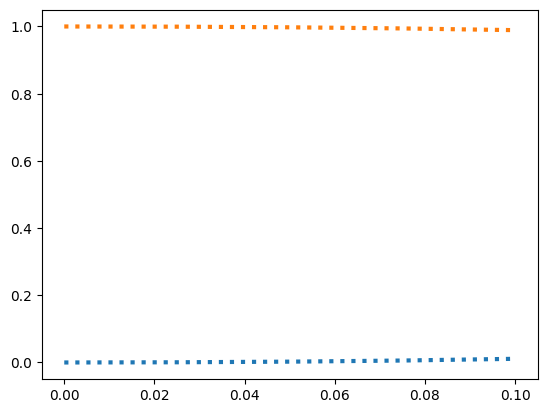

In [ ]:
# mean-field solution
L_table = np.linspace(0, L, t_steps)
sol     = P_osc_RS(L_table, theta, Delta, 0., abs(J)) # factor 2 because we compare to a system with 2 nu + 2 nubar
MFT_P_table = np.reshape(sol.y, (n_qubits,3,len(L_table)))

# P_table = np.reshape(sol.y, (4,3,len(L_table)))

plt.plot(L_table, 0.5*(1-MFT_P_table[0,2,:]), ls=':', lw=3)
plt.plot(L_table, 0.5*(1-MFT_P_table[-1,2,:]), ls=':', lw=3)

Adaptive step size total steps: 6


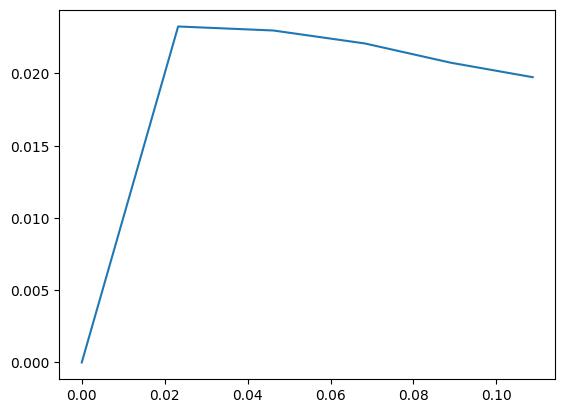

In [ ]:
# Calulate adaptive step size

slopes = np.linalg.norm(np.gradient(MFT_P_table, axis=2), axis=1)

max_slope = np.max(slopes, axis=0)

from scipy import interpolate

max_slope_interp = interpolate.interp1d(L_table, max_slope, kind='cubic')

adaptive_l_table = [L_table[0]]

curr_l = L_table[0]
MAX_STEP = L_table[-1] / 10

max_slope_per_step = 1 / (L_table[-1] / np.max(max_slope)) / MAX_SLOPE_CST

while curr_l < L_table[-1]:
    curr_slope = max_slope_interp(curr_l)
    # print(curr_slope)
    if curr_slope < 1e-6:
        curr_l += MAX_STEP
        adaptive_l_table.append(curr_l)
    else:
        curr_l += max_slope_per_step / curr_slope
        # print(max_slope_per_step / curr_slope)
        adaptive_l_table.append(curr_l)

adaptive_l_table = np.array(adaptive_l_table)

plt.plot(adaptive_l_table, np.diff(adaptive_l_table, prepend=0))

print("Adaptive step size total steps:", len(adaptive_l_table))

In [ ]:
from scipy.linalg import expm

def self_interact_nunu(theta):
    """
    returns the interaction term for nunu and nubarnubar interactions
    Friedland & Lunardini type
    """

    block = np.asarray([
        [2, 0, 0, 0],
        [0, 1, 1, 0],
        [0, 1, 1, 0],
        [0, 0, 0, 2]
    ])

    return expm(-1j * theta * block)

def self_interact_nunubar(theta):
    """
    returns the interaction term for nunubar interactions
    """

    block = np.array([[ 1,0,0,0],
                    [ 0,-1,2,0],
                    [ 0,2,-1,0],
                    [ 0,0,0,1]])

    return expm(-1j * theta * block)

In [ ]:
def initialize_from_rdm(qc, rdms):
    """
    We want to initialize an empty circuit (all |0>) to the state given by the reduced density matrices (rdms).
    """
    for k in range(len(rdms)):
        p = np.real(np.array([np.trace(sigma_1 @ rdms[k]), 
                          np.trace(sigma_2 @ rdms[k]), 
                          np.trace(sigma_3 @ rdms[k])]))
        qc.ry(np.arccos(p[2]), k)
        qc.rz(np.arctan2(p[1], p[0]), k)

def build_one_step_circuit(dt, rdms=None):
    """
    Builds the evolution circuit for a single time step of dt.
    """
    # If reduced density matrices are given, initialize the circuit from them
    qc = qk.QuantumCircuit(n_qubits)
    if rdms is not None:
        qc.initialize_from_rdm(qc, rdms)

    # Apply the vacuum interaction term
    for j in range(n_qubits):
        qc.rx(-dt*Delta[j]*b[0], j)
        qc.rz(-dt*Delta[j]*b[2], j)

    # Apply the self-interaction term
    for iq1 in range(n_qubits):
        for iq2 in range(iq1+1, n_qubits):
            if nu_mask[iq1] ^ nu_mask[iq2]:
                qc.unitary(self_interact_nunu(-dt*J[iq1, iq2]), [iq1, iq2])
            else:
                qc.unitary(self_interact_nunubar(-dt*J[iq1, iq2]), [iq1, iq2])

def evaluate_rdm(qc):
    converter = tn.CircuitToEinsum(qc)
    qubits = qc.qubits

    rdms = []

    # evaluate the reduced density matrices one by one
    for i in range(len(qubits)):
        where = (qubits[i],)
        fixed = {} # generate unbiased
        expr, operd = converter.reduced_density_matrix(where, fixed = fixed)

        # use simple contraction for now
        tmp_rdm = tn.contract(expr, *operd)

        # reshape and convert to numpy array
        tmp_rdm = tmp_rdm.reshape(2, 2)
        tmp_rdm = np.array(tmp_rdm)

        # normalize
        tmp_rdm /= np.trace(tmp_rdm)

        rdms.append(tmp_rdm)

    return rdms

def get_initial_rdms():
    rdms = []

    for isnu in nu_mask:
        if isnu:
            rdms.append(np.array([[1, 0], [0, 0]]))  # |nu><nu|
        else:
            rdms.append(np.array([[0, 0], [0, 1]])) # |nubar><nubar|


In [ ]:
dt_table = np.diff(adaptive_l_table, prepend=0)

rdm_step_dict = {}

rdm_step_dict[0] = get_initial_rdms()

print("Calculation start ...")

for i, dt in tqdm(enumerate(dt_table)):

    if i == 0:
        continue

    qc = build_one_step_circuit(dt, rdms=rdm_step_dict[i-1])
    rdms = evaluate_rdm(qc)
    rdm_step_dict[i] = rdms

print("All reduced density matrices calculated.")

In [ ]:
# Convert everything to probabilities and plot

print("Converting to probabilities ...")

prob = np.zeros((n_qubits, len(dt_table)))

for it in range(len(dt_table)):
    for k in range(n_qubits):
        prob[k, it] = np.abs(rdm_step_dict[it][k][0, 0])

print("Finished converting to probabilities.")


In [ ]:
plt.plot(L_table, 0.5*(1-MFT_P_table[0,2,:]), ls=':', lw=3)
plt.plot(L_table, 0.5*(1-MFT_P_table[-1,2,:]), ls=':', lw=3)

plt.plot(adaptive_l_table, prob[0, :], color='orange')
plt.plot(adaptive_l_table, prob[-1, :], color='blue')

plt.savefig("test.png")